In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install timm peft lightly -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 870.7/870.7 kB 16.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1

In [3]:
import timm
import peft

print("timm:", timm.__version__)
print("peft imported successfully")

timm: 1.0.26
peft imported successfully


In [4]:
import torch
import timm
import peft

print(torch.__version__)
print(timm.__version__)
print("PEFT OK")

2.10.0+cu128
1.0.26
PEFT OK


In [5]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [7]:
import timm

models = timm.list_models("*mae*")
print(models[:50])

[]


In [8]:
import timm

model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=0
)

print(type(model))

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

<class 'timm.models.vision_transformer.VisionTransformer'>


In [9]:
import torch

device = torch.device("cuda")

model = model.to(device)

dummy = torch.randn(1,3,224,224).to(device)

with torch.no_grad():
    feat = model(dummy)

print(feat.shape)

torch.Size([1, 384])


In [10]:
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

trainset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print(len(trainset), len(testset))

100%|██████████| 170M/170M [00:09<00:00, 18.3MB/s] 


50000 10000


In [11]:
for p in model.parameters():
    p.requires_grad = False

print("Backbone frozen")

Backbone frozen


In [12]:
import torch.nn as nn

probe = nn.Linear(
    384,
    10
).to(device)

print(probe)

Linear(in_features=384, out_features=10, bias=True)


In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    probe.parameters(),
    lr=1e-3
)

In [14]:
from tqdm import tqdm

linear_losses = []

for epoch in range(3):

    probe.train()

    running_loss = 0

    for images, labels in tqdm(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            features = model(images)

        logits = probe(features)

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    linear_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}: {avg_loss:.4f}"
    )

100%|██████████| 782/782 [03:01<00:00,  4.32it/s]


Epoch 1: 0.2389


100%|██████████| 782/782 [03:09<00:00,  4.12it/s]


Epoch 2: 0.1474


100%|██████████| 782/782 [03:09<00:00,  4.13it/s]

Epoch 3: 0.1372


In [15]:
probe.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        features = model(images)

        logits = probe(features)

        pred = logits.argmax(dim=1)

        correct += (pred == labels).sum().item()

        total += labels.size(0)

linear_acc = 100 * correct / total

print(
    f"Linear Probe Accuracy = {linear_acc:.2f}%"
)

Linear Probe Accuracy = 94.66%


In [16]:
for name, module in model.named_modules():
    if "qkv" in name.lower():
        print(name)

blocks.0.attn.qkv
blocks.1.attn.qkv
blocks.2.attn.qkv
blocks.3.attn.qkv
blocks.4.attn.qkv
blocks.5.attn.qkv
blocks.6.attn.qkv
blocks.7.attn.qkv
blocks.8.attn.qkv
blocks.9.attn.qkv
blocks.10.attn.qkv
blocks.11.attn.qkv


In [17]:
import timm
import torch

lora_backbone = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=0
)

lora_backbone = lora_backbone.to(device)

In [18]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["qkv"],
    lora_dropout=0.1,
    bias="none"
)

lora_backbone = get_peft_model(
    lora_backbone,
    config
)

lora_backbone.print_trainable_parameters()

trainable params: 147,456 || all params: 21,813,120 || trainable%: 0.6760


In [19]:
import torch.nn as nn

head = nn.Linear(
    384,
    10
).to(device)

In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    list(lora_backbone.parameters()) +
    list(head.parameters()),
    lr=1e-4
)

In [21]:
from tqdm import tqdm

lora_losses = []

for epoch in range(3):

    lora_backbone.train()

    running_loss = 0

    for images, labels in tqdm(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        features = lora_backbone(images)

        logits = head(features)

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    lora_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}: {avg_loss:.4f}"
    )

100%|██████████| 782/782 [07:24<00:00,  1.76it/s]


Epoch 1: 0.3956


100%|██████████| 782/782 [07:23<00:00,  1.77it/s]


Epoch 2: 0.0640


100%|██████████| 782/782 [07:23<00:00,  1.76it/s]

Epoch 3: 0.0464


In [22]:
lora_backbone.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        features = lora_backbone(images)

        logits = head(features)

        pred = logits.argmax(dim=1)

        correct += (
            pred == labels
        ).sum().item()

        total += labels.size(0)

lora_acc = 100 * correct / total

print(
    f"LoRA Accuracy = {lora_acc:.2f}%"
)

LoRA Accuracy = 97.60%


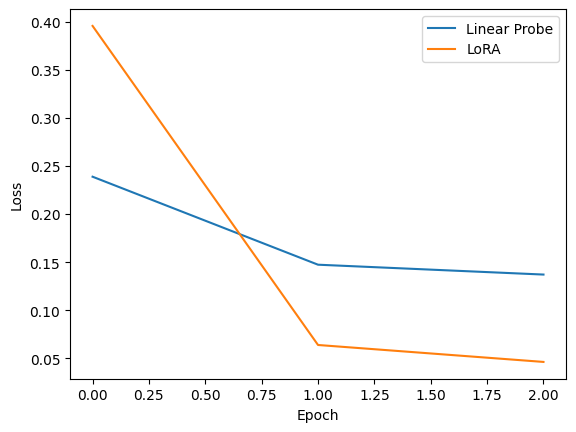

In [23]:
import matplotlib.pyplot as plt

plt.plot(
    linear_losses,
    label="Linear Probe"
)

plt.plot(
    lora_losses,
    label="LoRA"
)

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [24]:
import pandas as pd

results = pd.DataFrame({
    "Protocol": [
        "Linear Probe",
        "LoRA Fine-Tune"
    ],
    "Accuracy": [
        linear_acc,
        lora_acc
    ]
})

results

,Protocol,Accuracy
0,Linear Probe,94.66
1,LoRA Fine-Tune,97.60


In [25]:
!pip install transformers -q

In [26]:
from transformers import AutoImageProcessor, ViTMAEModel
import torch

device = torch.device("cuda")

processor = AutoImageProcessor.from_pretrained(
    "facebook/vit-mae-base"
)

mae = ViTMAEModel.from_pretrained(
    "facebook/vit-mae-base"
)

mae = mae.to(device)

print("Loaded")

preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_embed.bias                                                       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

Loaded


In [27]:
dummy = torch.randn(
    1,3,224,224
).to(device)

with torch.no_grad():

    outputs = mae(
        pixel_values=dummy
    )

print(
    outputs.last_hidden_state.shape
)

torch.Size([1, 50, 768])


In [28]:
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

trainset = CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transform
)

testset = CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

In [29]:
for p in mae.parameters():
    p.requires_grad = False

In [30]:
import torch.nn as nn

probe = nn.Linear(
    768,
    10
).to(device)

In [31]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    probe.parameters(),
    lr=1e-3
)

In [32]:
from tqdm import tqdm

linear_losses = []

for epoch in range(3):

    probe.train()

    running_loss = 0

    for images, labels in tqdm(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():

            outputs = mae(
                pixel_values=images
            )

            features = outputs.last_hidden_state[:,0]

        logits = probe(features)

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    linear_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}: {avg_loss:.4f}"
    )

100%|██████████| 782/782 [03:21<00:00,  3.88it/s]


Epoch 1: 1.5827


100%|██████████| 782/782 [03:20<00:00,  3.90it/s]


Epoch 2: 1.2039


100%|██████████| 782/782 [03:21<00:00,  3.89it/s]

Epoch 3: 1.0800


In [33]:
probe.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mae(
            pixel_values=images
        )

        features = outputs.last_hidden_state[:,0]

        logits = probe(features)

        pred = logits.argmax(1)

        correct += (
            pred == labels
        ).sum().item()

        total += labels.size(0)

linear_acc = 100 * correct / total

print(
    f"Linear Probe Accuracy: {linear_acc:.2f}%"
)

Linear Probe Accuracy: 65.20%


In [34]:
for name,_ in mae.named_modules():

    if "query" in name.lower():
        print(name)

encoder.layer.0.attention.attention.query
encoder.layer.1.attention.attention.query
encoder.layer.2.attention.attention.query
encoder.layer.3.attention.attention.query
encoder.layer.4.attention.attention.query
encoder.layer.5.attention.attention.query
encoder.layer.6.attention.attention.query
encoder.layer.7.attention.attention.query
encoder.layer.8.attention.attention.query
encoder.layer.9.attention.attention.query
encoder.layer.10.attention.attention.query
encoder.layer.11.attention.attention.query


In [35]:
from peft import LoraConfig
from peft import get_peft_model

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "query",
        "value"
    ],
    lora_dropout=0.1,
    bias="none"
)

mae_lora = get_peft_model(
    mae,
    config
)

mae_lora.print_trainable_parameters()

trainable params: 294,912 || all params: 86,093,568 || trainable%: 0.3425


In [36]:
head = nn.Linear(
    768,
    10
).to(device)

In [37]:
optimizer = optim.AdamW(
    list(mae_lora.parameters()) +
    list(head.parameters()),
    lr=1e-4
)

In [38]:
lora_losses = []

for epoch in range(3):

    mae_lora.train()

    running_loss = 0

    for images, labels in tqdm(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = mae_lora(
            pixel_values=images
        )

        features = outputs.last_hidden_state[:,0]

        logits = head(features)

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)

    lora_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}: {avg_loss:.4f}"
    )

100%|██████████| 782/782 [06:08<00:00,  2.12it/s]


Epoch 1: 1.1344


100%|██████████| 782/782 [06:09<00:00,  2.12it/s]


Epoch 2: 0.4765


100%|██████████| 782/782 [06:08<00:00,  2.12it/s]

Epoch 3: 0.3787


In [39]:
correct = 0
total = 0

mae_lora.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mae_lora(
            pixel_values=images
        )

        features = outputs.last_hidden_state[:,0]

        logits = head(features)

        pred = logits.argmax(1)

        correct += (
            pred == labels
        ).sum().item()

        total += labels.size(0)

lora_acc = 100 * correct / total

print(
    f"LoRA Accuracy: {lora_acc:.2f}%"
)

LoRA Accuracy: 87.84%


In [40]:
print(linear_losses)
print(lora_losses)


[1.5826891903072366, 1.2039481636965672, 1.0799904558664697]
[1.1343780226643434, 0.4765386571512198, 0.37869130421782393]


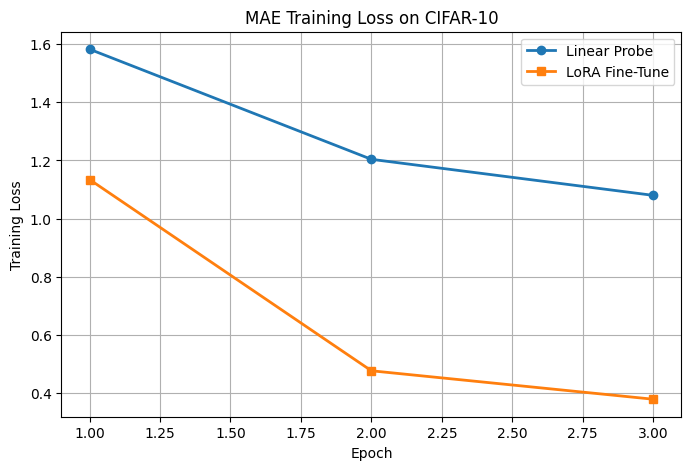

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

epochs = [1,2,3]

plt.plot(
    epochs,
    linear_losses,
    marker='o',
    linewidth=2,
    label='Linear Probe'
)

plt.plot(
    epochs,
    lora_losses,
    marker='s',
    linewidth=2,
    label='LoRA Fine-Tune'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MAE Training Loss on CIFAR-10")

plt.legend()
plt.grid(True)

plt.show()

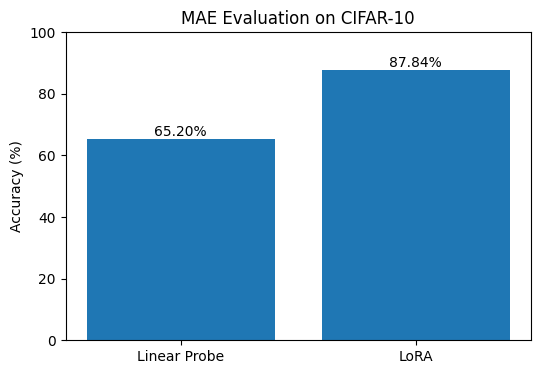

In [42]:
import matplotlib.pyplot as plt

methods = [
    "Linear Probe",
    "LoRA"
]

accuracies = [
    65.20,
    87.84
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    methods,
    accuracies
)

plt.ylabel("Accuracy (%)")
plt.title("MAE Evaluation on CIFAR-10")

for bar, acc in zip(bars, accuracies):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        acc+1,
        f"{acc:.2f}%",
        ha='center'
    )

plt.ylim(0,100)

plt.show()